# CaSR Weights File Correction for Air Temperature

## Why do we need it?

`CaSR` has low resolution. Some of its grid points represent larger area compared to `HRDPS`, including both land and sea. Air above land and sea has different temperature. Moreover, the land area also impacts the `altitude` for temperature reference points.

See https://github.com/SalishSeaCast/analysis-junqi/blob/main/Analysis_Atmospheric_Forcing/Analysis_forcing_comparison/Analysis_weights/Fjords.ipynb for more information.

See `/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/CaSR_2023_Results.ipynb` for height information.

## How do we want to correct it?

The simplest way of correcting it is to change the `weights file` for temperature only. For a grid point in `SalishSeaCast`, it involves 4 grid points in `CaSR`, using double-linear interpolation. 

**How we want to produce the new weights file:**

1. if all 4 grid points in `CaSR` are sea points (0 height in `CaSR_v3.2_P_GZ_SFC.nc`), the indexes and the weights of the grid points needed stay the same;

2. if some but not every of the 4 grid point are land points, set the weights of the land points to zero and renormalize the weights of the remaining sea points so that their sum is 1;

3. if all the grid points are land points, find the nearest sea point and use it (weight=1). 

*Note: in case of height=0.000001, all heights < 1 are considered sea points*

**Where to find the files**

Height file: `/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_CaSR_Altitude/CaSR_v3.2_P_GZ_SFC.nc`

`CaSR` weight file: `/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Data_weights/weights-CaSR_202108.nc`



### How would others describe it/ solve it?

See https://journals.ametsoc.org/view/journals/phoc/37/4/jpo2984.1.xml?utm_source=chatgpt.com 



## Correction

In [1]:
from pathlib import Path

import numpy as np
import xarray as xr
from scipy.spatial import cKDTree


# ============================================================
# Paths
# ============================================================

ALTITUDE_FILE = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_results_comparison/"
    "00MMM2023/"
    "Data_CaSR_Altitude/"
    "CaSR_v3.2_P_GZ_SFC.nc"
)

WEIGHTS_FILE = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Data_weights/"
    "weights-CaSR_202108.nc"
)

OUTPUT_FILE = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Data_weights/"
    "weights-CaSR_202108_temp_corrected.nc"
)


# ============================================================
# Settings
# ============================================================

ALT_VAR = "CaSR_v3.2_P_GZ_SFC"

# Treat CaSR points with surface altitude < 1 as sea points
SEA_HEIGHT_THRESHOLD = 1.0


# ============================================================
# Helper functions
# ============================================================

def lonlat_to_xyz(lon, lat):
    """
    Convert lon/lat in degrees to Cartesian coordinates on a unit sphere.

    This allows nearest-neighbour searching with cKDTree without treating
    longitude/latitude as simple Cartesian coordinates.
    """
    lon_rad = np.deg2rad(lon)
    lat_rad = np.deg2rad(lat)

    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)

    return np.stack([x, y, z], axis=-1)


# ============================================================
# Read files
# ============================================================

print("Reading CaSR altitude file:")
print(f"  {ALTITUDE_FILE}")

alt_ds = xr.open_dataset(ALTITUDE_FILE)

print("\nReading original weights file:")
print(f"  {WEIGHTS_FILE}")

weights = xr.open_dataset(WEIGHTS_FILE).load()


# ============================================================
# Read CaSR source-grid information
# ============================================================

altitude = alt_ds[ALT_VAR].transpose("rlat", "rlon")

lat = alt_ds["lat"].transpose("rlat", "rlon")
lon = alt_ds["lon"].transpose("rlat", "rlon")

nlat = altitude.sizes["rlat"]
nlon = altitude.sizes["rlon"]
nsource = nlat * nlon

print("\nCaSR source grid:")
print(f"  nlat    = {nlat}")
print(f"  nlon    = {nlon}")
print(f"  nsource = {nsource}")

print("\nAltitude information:")
print(f"  units = {altitude.attrs.get('units', 'not specified')}")
print(f"  min   = {float(altitude.min(skipna=True))}")
print(f"  max   = {float(altitude.max(skipna=True))}")


# ============================================================
# Define CaSR sea points
# ============================================================

alt_values = altitude.values

sea_mask = (
    np.isfinite(alt_values)
    & (alt_values < SEA_HEIGHT_THRESHOLD)
)

land_mask = ~sea_mask

nsea = int(sea_mask.sum())
nland = int(land_mask.sum())

print("\nCaSR land/sea classification:")
print(f"  Sea threshold : altitude < {SEA_HEIGHT_THRESHOLD}")
print(f"  Sea points    : {nsea}")
print(f"  Land points   : {nland}")
print(f"  Sea fraction  : {nsea / nsource:.3%}")

if nsea == 0:
    raise RuntimeError(
        "No sea points were identified. "
        "Check the altitude variable and SEA_HEIGHT_THRESHOLD."
    )


# ============================================================
# Flatten CaSR grid
#
# IMPORTANT:
# src = i + nx * (j - 1)
#
# Therefore:
#
# Python index = src - 1
#
# and a C-order flattened (rlat, rlon) array corresponds to
# the source indexing in the weights file.
# ============================================================

sea_flat = sea_mask.ravel(order="C")

lat_flat = lat.values.ravel(order="C")
lon_flat = lon.values.ravel(order="C")


# ============================================================
# Read original src / wgt
# ============================================================

src_names = [f"src0{k}" for k in range(1, 5)]
wgt_names = [f"wgt0{k}" for k in range(1, 5)]

for name in src_names + wgt_names:
    if name not in weights:
        raise KeyError(f"{name} not found in weights file.")


# shape:
#
#     (4, y, x)
#
src = np.stack(
    [weights[name].values for name in src_names],
    axis=0,
)

wgt = np.stack(
    [weights[name].values for name in wgt_names],
    axis=0,
)


# ============================================================
# Sanity check source indices
# ============================================================

src_min = int(src.min())
src_max = int(src.max())

print("\nOriginal source-index range:")
print(f"  min = {src_min}")
print(f"  max = {src_max}")
print(f"  expected = 1 ... {nsource}")

if src_min < 1 or src_max > nsource:
    raise ValueError(
        "The source indices in the weights file are inconsistent "
        "with the CaSR altitude grid."
    )


# Convert Fortran 1-based source index -> Python 0-based
src_idx = src.astype(np.int64) - 1


# ============================================================
# Determine whether each of the four source points is sea
#
# shape:
#
#     (4, y, x)
# ============================================================

source_is_sea = sea_flat[src_idx]

n_sea_sources = source_is_sea.sum(axis=0)

all_four_sea = n_sea_sources == 4
some_sea = (n_sea_sources > 0) & (n_sea_sources < 4)
all_four_land = n_sea_sources == 0


print("\nClassification of SalishSeaCast target points:")
print(f"  4 sea sources : {int(all_four_sea.sum())}")
print(f"  1-3 sea       : {int(some_sea.sum())}")
print(f"  0 sea         : {int(all_four_land.sum())}")


# ============================================================
# Make copies that will be modified
# ============================================================

new_src = src.copy()
new_wgt = wgt.astype(np.float64, copy=True)


# ============================================================
# Case 1
#
# All four points are sea.
#
# Do absolutely nothing.
# ============================================================


# ============================================================
# Case 2
#
# Some, but not all, source points are land:
#
#   1. land weights -> 0
#   2. renormalize remaining sea weights
#
# src indices themselves are unchanged.
# ============================================================

for k in range(4):
    land_contributor = some_sea & (~source_is_sea[k])

    new_wgt[k, land_contributor] = 0.0


# Sum after zeroing land contributions
partial_sum = new_wgt.sum(axis=0)

# This should always be > 0 because these cells have >= 1 sea point.
if np.any(partial_sum[some_sea] <= 0):
    raise RuntimeError(
        "Found a partially-ocean target point whose remaining "
        "weights sum to zero."
    )


# Renormalize only the partial-land cases
for k in range(4):
    new_wgt[k, some_sea] /= partial_sum[some_sea]


# ============================================================
# Case 3
#
# All 4 original source points are land.
#
# We don't have the SalishSeaCast target lon/lat in the weights
# file itself.
#
# However, the original 4 CaSR source locations + bilinear
# weights give us a very good proxy for the target location.
#
# We calculate a weighted location on the sphere, then search
# for the closest CaSR sea point.
# ============================================================

if np.any(all_four_land):

    print("\nFinding nearest CaSR sea points for targets whose")
    print("four original source points are all land...")

    # --------------------------------------------------------
    # Build nearest-neighbour tree using ALL CaSR sea points
    # --------------------------------------------------------

    sea_indices_0based = np.flatnonzero(sea_flat)

    sea_lon = lon_flat[sea_indices_0based]
    sea_lat = lat_flat[sea_indices_0based]

    sea_xyz = lonlat_to_xyz(sea_lon, sea_lat)

    tree = cKDTree(sea_xyz)


    # --------------------------------------------------------
    # Original source lon/lat for the all-land target points
    #
    # Result shape:
    #     (4, N_all_land)
    # --------------------------------------------------------

    original_idx = src_idx[:, all_four_land]
    original_wgt = wgt[:, all_four_land].astype(np.float64)

    source_lon = lon_flat[original_idx]
    source_lat = lat_flat[original_idx]


    # --------------------------------------------------------
    # Convert each source point to XYZ on unit sphere
    #
    # shape:
    #     (4, N, 3)
    # --------------------------------------------------------

    source_xyz = lonlat_to_xyz(source_lon, source_lat)


    # --------------------------------------------------------
    # Weighted spherical location
    #
    # Original weights should sum to ~1, but normalize here
    # defensively.
    # --------------------------------------------------------

    weight_sum = original_wgt.sum(axis=0)

    if np.any(weight_sum == 0):
        raise RuntimeError(
            "Found an all-land target whose original weights sum to zero."
        )

    normalized_original_wgt = original_wgt / weight_sum[None, :]

    target_xyz = np.sum(
        source_xyz * normalized_original_wgt[..., None],
        axis=0,
    )

    # Normalize back onto unit sphere
    norm = np.linalg.norm(target_xyz, axis=1)

    if np.any(norm == 0):
        raise RuntimeError(
            "Could not determine proxy position for one or more target points."
        )

    target_xyz /= norm[:, None]


    # --------------------------------------------------------
    # Find nearest SEA point
    # --------------------------------------------------------

    distance, nearest_position = tree.query(
        target_xyz,
        k=1,
    )

    nearest_sea_idx_0based = sea_indices_0based[nearest_position]

    # Convert Python 0-based index back to the weights-file
    # Fortran 1-based src convention.
    nearest_sea_src = nearest_sea_idx_0based + 1


    # --------------------------------------------------------
    # For clarity, set all four src slots to the same nearest
    # sea point.
    #
    # Only src01 contributes because:
    #
    #     wgt01 = 1
    #     wgt02 = wgt03 = wgt04 = 0
    #
    # Setting all four src values to a valid sea source also
    # makes the resulting file easier to inspect.
    # --------------------------------------------------------

    for k in range(4):
        new_src[k, all_four_land] = nearest_sea_src

    new_wgt[:, all_four_land] = 0.0
    new_wgt[0, all_four_land] = 1.0


# ============================================================
# Final checks
# ============================================================

weight_sum_final = new_wgt.sum(axis=0)

print("\nFinal weight-sum statistics:")
print(f"  min = {weight_sum_final.min():.12f}")
print(f"  max = {weight_sum_final.max():.12f}")
print(
    "  maximum |sum - 1| = "
    f"{np.max(np.abs(weight_sum_final - 1.0)):.3e}"
)

if not np.allclose(
    weight_sum_final,
    1.0,
    atol=1e-6,
    rtol=0.0,
):
    raise RuntimeError(
        "Corrected weights do not sum to 1 everywhere."
    )


# Check that every source point that has non-zero weight is sea
new_idx = new_src.astype(np.int64) - 1

for k in range(4):

    contributing = new_wgt[k] > 0

    bad = (
        contributing
        & (~sea_flat[new_idx[k]])
    )

    if np.any(bad):
        raise RuntimeError(
            f"{src_names[k]} still contains land points "
            "with non-zero weights."
        )


print(
    "\nCheck passed: every source point with non-zero weight "
    "is classified as sea."
)


# ============================================================
# Put corrected arrays back into a copy of the Dataset
# ============================================================

corrected = weights.copy(deep=True)

for k in range(4):

    src_name = src_names[k]
    wgt_name = wgt_names[k]

    # Preserve original data types
    corrected[src_name].values[:] = new_src[k].astype(
        corrected[src_name].dtype
    )

    corrected[wgt_name].values[:] = new_wgt[k].astype(
        corrected[wgt_name].dtype
    )


# ============================================================
# Add documentation to global attributes
# ============================================================

corrected.attrs = corrected.attrs.copy()

corrected.attrs[
    "temperature_weights_correction"
] = (
    "CaSR source points with CaSR_v3.2_P_GZ_SFC < 1 were "
    "classified as sea. Land-source weights were set to zero "
    "and remaining sea-source weights renormalized. Where all "
    "four original source points were land, the nearest CaSR "
    "sea source point was used with weight 1."
)

corrected.attrs[
    "temperature_weights_sea_height_threshold"
] = SEA_HEIGHT_THRESHOLD

corrected.attrs[
    "temperature_weights_original_file"
] = str(WEIGHTS_FILE)

corrected.attrs[
    "temperature_weights_altitude_file"
] = str(ALTITUDE_FILE)


# ============================================================
# Write corrected file
# ============================================================

OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

corrected.to_netcdf(OUTPUT_FILE)

print("\nFinished.")
print(f"Corrected temperature weights written to:")
print(f"  {OUTPUT_FILE}")


# ============================================================
# Optional summary
# ============================================================

print("\nSummary:")
print(
    f"  unchanged (4 sea)       : "
    f"{int(all_four_sea.sum())}"
)
print(
    f"  renormalized (1-3 sea)  : "
    f"{int(some_sea.sum())}"
)
print(
    f"  nearest-sea replacement : "
    f"{int(all_four_land.sum())}"
)


alt_ds.close()
weights.close()
corrected.close()

Reading CaSR altitude file:
  /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_CaSR_Altitude/CaSR_v3.2_P_GZ_SFC.nc

Reading original weights file:
  /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Data_weights/weights-CaSR_202108.nc

CaSR source grid:
  nlat    = 105
  nlon    = 70
  nsource = 7350

Altitude information:
  units = dam
  min   = 0.0
  max   = 222.46896362304688

CaSR land/sea classification:
  Sea threshold : altitude < 1.0
  Sea points    : 1620
  Land points   : 5730
  Sea fraction  : 22.041%

Original source-index range:
  min = 2263
  max = 5499
  expected = 1 ... 7350

Classification of SalishSeaCast target points:
  4 sea sources : 12599
  1-3 sea       : 58693
  0 sea         : 286112

Finding nearest CaSR sea points for targets whose
four original source points are all land...

Final weight-sum statistics:
  min = 1.000000000000
  max = 1.000000000000
  maximum |sum - 1| = 3.331e-16

Check passed: every sou

## Take a look at NEW points

In [2]:
# Track function

import xarray as xr
import numpy as np


# ============================================================
# Weight files
# ============================================================

path_weights_casr = (
    '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Data_weights/weights-CaSR_202108_temp_corrected.nc'
)

path_weights_hrdps = (
    '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/'
    'Data_weights/weights-continental2.5-hrdps.nc'
)

ds_weights_casr = xr.open_dataset(path_weights_casr)
ds_weights_hrdps = xr.open_dataset(path_weights_hrdps)


# ============================================================
# Stations: NEMO T-grid index
# ============================================================

stations = {
    'Pam Rocks': {
        'y': 502,
        'x': 341,
        'lat': 49.487434,
        'lon': -123.30153,
    },

    'Sand Heads': {
        'y': 428,
        'x': 293,
        'lat': 49.107586,
        'lon': -123.30203,
    },
}


# ============================================================
# Function
# ============================================================

def print_atmos_source_points(weights, y, x, name=None):
    """
    Print the atmospheric grid points used to interpolate
    one NEMO target grid point (y, x).

    Parameters
    ----------
    weights : xr.Dataset
        NEMO atmospheric interpolation weights file.
        Must contain:
            nav_lat(lat, lon)
            nav_lon(lat, lon)
            src01..src04(y, x)
            wgt01..wgt04(y, x)

    y, x : int
        Zero-based Python indices of the NEMO target grid point.

    name : str, optional
        Name of the target point, for display.
    """

    nlat = weights.sizes["lat"]
    nlon = weights.sizes["lon"]

    if name is None:
        name = "NEMO point"

    print("=" * 80)
    print(f"{name}")
    print(f"NEMO target index: y={y}, x={x}")
    print(f"Atmospheric source grid: nlat={nlat}, nlon={nlon}")
    print("=" * 80)

    weight_sum = 0.0

    for k in range(1, 5):

        src_name = f"src0{k}"
        wgt_name = f"wgt0{k}"

        # ----------------------------------------------------
        # src is Fortran 1-based linear index
        # ----------------------------------------------------
        src = int(weights[src_name].isel(y=y, x=x).item())
        wgt = float(weights[wgt_name].isel(y=y, x=x).item())

        # Fortran 1-based -> Python 0-based
        idx = src - 1

        # Reverse:
        #
        # Fortran:
        #     src = i + nlon * (j - 1)
        #
        # Python:
        #     idx = ilat * nlon + ilon
        #
        ilat = idx // nlon
        ilon = idx % nlon

        # source atmospheric coordinates
        atmos_lat = float(
            weights["nav_lat"].isel(lat=ilat, lon=ilon).item()
        )

        atmos_lon = float(
            weights["nav_lon"].isel(lat=ilat, lon=ilon).item()
        )

        weight_sum += wgt

        print(
            f"source {k}: "
            f"src={src:6d}, "
            f"(ilat, ilon)=({ilat:4d}, {ilon:4d}), "
            f"lat={atmos_lat:10.6f}, "
            f"lon={atmos_lon:11.6f}, "
            f"weight={wgt:.10f}"
        )

    print("-" * 80)
    print(f"sum(weights) = {weight_sum:.12f}")
    print()



In [3]:
# ============================================================
# CaSR
# ============================================================

print("\n\n#################### CaSR ####################\n")

for station_name, station in stations.items():

    print(
        f"Station coordinate: "
        f"lat={station['lat']}, lon={station['lon']}"
    )

    print_atmos_source_points(
        ds_weights_casr,
        y=station["y"],
        x=station["x"],
        name=station_name,
    )


# ============================================================
# HRDPS
# ============================================================

print("\n\n#################### HRDPS ####################\n")

for station_name, station in stations.items():

    print(
        f"Station coordinate: "
        f"lat={station['lat']}, lon={station['lon']}"
    )

    print_atmos_source_points(
        ds_weights_hrdps,
        y=station["y"],
        x=station["x"],
        name=station_name,
    )



#################### CaSR ####################

Station coordinate: lat=49.487434, lon=-123.30153
Pam Rocks
NEMO target index: y=502, x=341
Atmospheric source grid: nlat=105, nlon=70
source 1: src=  4025, (ilat, ilon)=(  57,   34), lat= 49.323540, lon= 236.489075, weight=1.0000000000
source 2: src=  4025, (ilat, ilon)=(  57,   34), lat= 49.323540, lon= 236.489075, weight=0.0000000000
source 3: src=  4025, (ilat, ilon)=(  57,   34), lat= 49.323540, lon= 236.489075, weight=0.0000000000
source 4: src=  4025, (ilat, ilon)=(  57,   34), lat= 49.323540, lon= 236.489075, weight=0.0000000000
--------------------------------------------------------------------------------
sum(weights) = 1.000000000000

Station coordinate: lat=49.107586, lon=-123.30203
Sand Heads
NEMO target index: y=428, x=293
Atmospheric source grid: nlat=105, nlon=70
source 1: src=  3815, (ilat, ilon)=(  54,   34), lat= 49.081009, lon= 236.670670, weight=0.8214254999
source 2: src=  3885, (ilat, ilon)=(  55,   34), lat= 49.

Pam Rocks extent: [np.float64(-123.59092499999998), np.float64(-123.19097600000002), np.float64(49.24354), np.float64(49.586548)]
Sand Heads extent: [np.float64(-123.469679), np.float64(-123.12613100000003), np.float64(49.001009), np.float64(49.28121)]


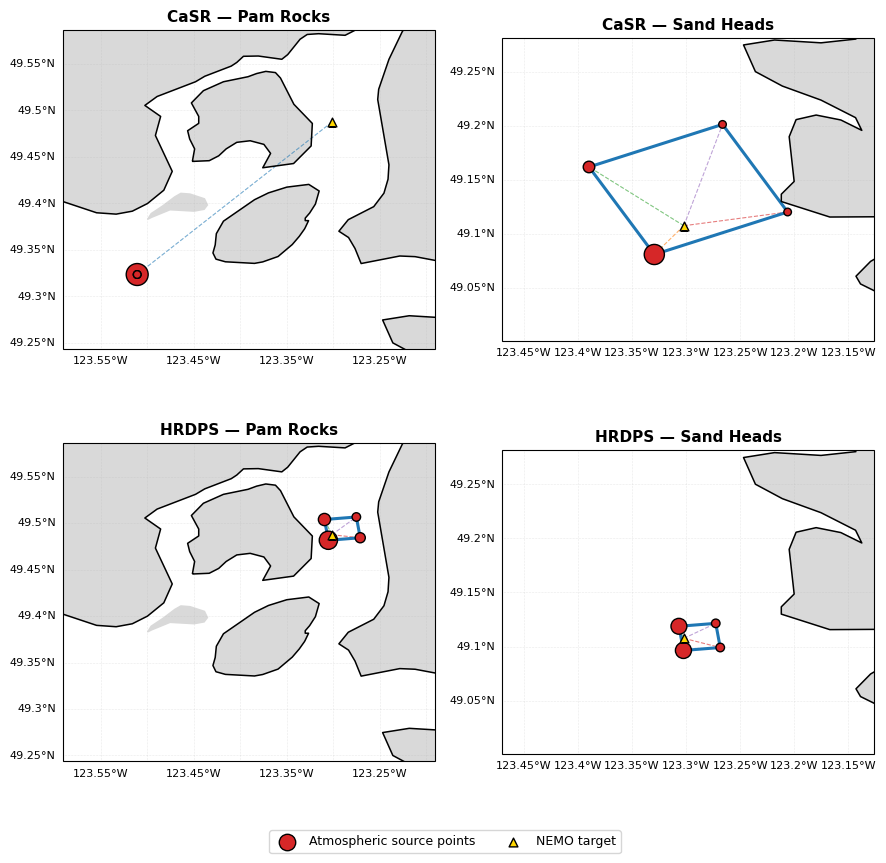

In [4]:
# Visualize

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ============================================================
# Helper: convert longitude from 0--360 to -180--180
# ============================================================
def lon180(lon):
    return ((lon + 180) % 360) - 180


# ============================================================
# NEMO target stations -- NEW coordinates
# ============================================================
stations = {
    "Pam Rocks": {
        "y": 502,
        "x": 341,
        "lat": 49.487434,
        "lon": -123.30153,
    },
    "Sand Heads": {
        "y": 428,
        "x": 293,
        "lat": 49.107586,
        "lon": -123.30203,
    },
}


# ============================================================
# Atmospheric interpolation sources -- NEW coordinates/weights
# Only the actual source points are retained; neighbor/edge
# points are intentionally omitted.
# ============================================================
def make_source_df(rows):
    return pd.DataFrame(
        rows,
        columns=[
            "source_number",
            "src",
            "atmos_ilat",
            "atmos_ilon",
            "atmos_lat",
            "atmos_lon",
            "weight",
        ],
    )


casr_results = {
    "Pam Rocks": make_source_df([
        (1, 4025, 57, 34, 49.323540, 236.489075, 1.0000000000),
        (2, 4025, 57, 34, 49.323540, 236.489075, 0.0000000000),
        (3, 4025, 57, 34, 49.323540, 236.489075, 0.0000000000),
        (4, 4025, 57, 34, 49.323540, 236.489075, 0.0000000000),
    ]),
    "Sand Heads": make_source_df([
        (1, 3815, 54, 34, 49.081009, 236.670670, 0.8214254999),
        (2, 3885, 55, 34, 49.161884, 236.610321, 0.1785745001),
        (3, 3816, 54, 35, 49.120274, 236.793869, 0.0000000000),
        (4, 3886, 55, 35, 49.201210, 236.733704, 0.0000000000),
    ]),
}


hrdps_results = {
    "Pam Rocks": make_source_df([
        (1, 25761, 135, 110, 49.481496, 236.694728, 0.6461993583),
        (2, 25951, 136, 110, 49.503828, 236.690528, 0.2141754176),
        (3, 25762, 135, 111, 49.484212, 236.729024, 0.1048679398),
        (4, 25952, 136, 111, 49.506548, 236.724832, 0.0347572843),
    ]),
    "Sand Heads": make_source_df([
        (1, 22529, 118, 108, 49.096376, 236.697576, 0.4704031405),
        (2, 22719, 119, 108, 49.118712, 236.693408, 0.4576466227),
        (3, 22530, 118, 109, 49.099092, 236.731584, 0.0364696148),
        (4, 22720, 119, 109, 49.121428, 236.727432, 0.0354806220),
    ]),
}


# ============================================================
# Helper: calculate common extent for the same station
# ============================================================
def get_common_extent(dfs, station, padding=0.08):
    all_lon = []
    all_lat = []

    for df in dfs:
        all_lon.extend(lon180(df["atmos_lon"].values))
        all_lat.extend(df["atmos_lat"].values)

    all_lon.append(lon180(station["lon"]))
    all_lat.append(station["lat"])

    all_lon = np.asarray(all_lon)
    all_lat = np.asarray(all_lat)

    return [
        all_lon.min() - padding,
        all_lon.max() + padding,
        all_lat.min() - padding,
        all_lat.max() + padding,
    ]


# ============================================================
# Plot one panel
# ============================================================
def plot_atmos_weights_map(ax, df, station, title, extent=None, padding=0.08):
    """
    Plot only the atmospheric source points actually used.

    Removed from the old version:
      - neighbor/edge atmospheric points
      - grid lines extending through neighbor points

    Retained:
      - NEMO target
      - source points
      - interpolation cell when at least 3 distinct source points exist
      - dashed target-to-source lines
      - coastline/land
    """
    df = df.copy()
    df["plot_lon"] = lon180(df["atmos_lon"])

    target_lon = lon180(station["lon"])
    target_lat = station["lat"]

    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.1, zorder=10)

    # --------------------------------------------------------
    # Source points actually used
    # --------------------------------------------------------
    marker_sizes = 30 + 220 * df["weight"].values

    ax.scatter(
        df["plot_lon"],
        df["atmos_lat"],
        s=marker_sizes,
        marker="o",
        facecolors="tab:red",
        edgecolors="black",
        linewidths=1.0,
        transform=ccrs.PlateCarree(),
        zorder=6,
        label="Atmospheric source points",
    )

    # --------------------------------------------------------
    # Interpolation cell
    # Use distinct coordinates so duplicated source entries
    # (e.g. CaSR Pam Rocks) do not create a degenerate polygon.
    # --------------------------------------------------------
    unique_pts = (
        df[["plot_lon", "atmos_lat"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    if len(unique_pts) >= 3:
        center_lon = unique_pts["plot_lon"].mean()
        center_lat = unique_pts["atmos_lat"].mean()

        angle = np.arctan2(
            unique_pts["atmos_lat"].values - center_lat,
            unique_pts["plot_lon"].values - center_lon,
        )
        order = np.argsort(angle)
        polygon = unique_pts.iloc[order]

        poly_lon = np.append(polygon["plot_lon"].values, polygon["plot_lon"].values[0])
        poly_lat = np.append(polygon["atmos_lat"].values, polygon["atmos_lat"].values[0])

        ax.plot(
            poly_lon,
            poly_lat,
            "-",
            linewidth=2.2,
            transform=ccrs.PlateCarree(),
            zorder=5,
            label="Interpolation cell",
        )

    # --------------------------------------------------------
    # NEMO target
    # --------------------------------------------------------
    ax.scatter(
        target_lon,
        target_lat,
        marker="^",
        s=40,
        facecolors="gold",
        edgecolors="black",
        linewidths=1.0,
        transform=ccrs.PlateCarree(),
        zorder=8,
        label="NEMO target",
    )

    # --------------------------------------------------------
    # Lines from target to distinct source positions
    # --------------------------------------------------------
    for _, row in unique_pts.iterrows():
        ax.plot(
            [target_lon, row["plot_lon"]],
            [target_lat, row["atmos_lat"]],
            "--",
            linewidth=0.8,
            alpha=0.6,
            transform=ccrs.PlateCarree(),
            zorder=3,
        )

    # --------------------------------------------------------
    # Map extent
    # --------------------------------------------------------
    if extent is None:
        all_lon = np.concatenate([df["plot_lon"].values, [target_lon]])
        all_lat = np.concatenate([df["atmos_lat"].values, [target_lat]])
        extent = [
            all_lon.min() - padding,
            all_lon.max() + padding,
            all_lat.min() - padding,
            all_lat.max() + padding,
        ]

    ax.set_extent(extent, crs=ccrs.PlateCarree())

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.4,
        alpha=0.5,
        linestyle=":",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}

    ax.set_title(title, fontsize=11, fontweight="bold")


# ============================================================
# Common extents: same station uses the same range for CaSR/HRDPS
# ============================================================
extent_pam = get_common_extent(
    [casr_results["Pam Rocks"], hrdps_results["Pam Rocks"]],
    stations["Pam Rocks"],
    padding=0.08,
)

extent_sand = get_common_extent(
    [casr_results["Sand Heads"], hrdps_results["Sand Heads"]],
    stations["Sand Heads"],
    padding=0.08,
)

print("Pam Rocks extent:", extent_pam)
print("Sand Heads extent:", extent_sand)


# ============================================================
# Make 2 x 2 figure
# ============================================================
fig, axes = plt.subplots(
    2,
    2,
    figsize=(9, 9),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

plot_atmos_weights_map(
    axes[0, 0],
    casr_results["Pam Rocks"],
    stations["Pam Rocks"],
    title="CaSR — Pam Rocks",
    extent=extent_pam,
)

plot_atmos_weights_map(
    axes[0, 1],
    casr_results["Sand Heads"],
    stations["Sand Heads"],
    title="CaSR — Sand Heads",
    extent=extent_sand,
)

plot_atmos_weights_map(
    axes[1, 0],
    hrdps_results["Pam Rocks"],
    stations["Pam Rocks"],
    title="HRDPS — Pam Rocks",
    extent=extent_pam,
)

plot_atmos_weights_map(
    axes[1, 1],
    hrdps_results["Sand Heads"],
    stations["Sand Heads"],
    title="HRDPS — Sand Heads",
    extent=extent_sand,
)


# ============================================================
# Common legend
# ============================================================
handles, labels = axes[0, 0].get_legend_handles_labels()
unique = {}
for h, label in zip(handles, labels):
    if label not in unique:
        unique[label] = h

fig.legend(
    unique.values(),
    unique.keys(),
    loc="lower center",
    ncol=2,
    fontsize=9,
    frameon=True,
    bbox_to_anchor=(0.5, 0.015),
)

plt.tight_layout(rect=[0, 0.06, 1, 1])

# Optional save
# plt.savefig(
#     "NEMO_atmospheric_interpolation_geometry_new.png",
#     dpi=300,
#     bbox_inches="tight",
# )

plt.show()

## Take a look at results

### Map

Date        : 20230301
Time index  : 0
HRDPS 1 time   : 2023-03-01T12:00:00.000000000
HRDPS time  : 2023-03-01T12:00:00.000000000
HRDPS 1 shape  : (898, 398)
HRDPS shape : (898, 398)
Date        : 20230315
Time index  : 14
HRDPS 1 time   : 2023-03-15T12:00:00.000000000
HRDPS time  : 2023-03-15T12:00:00.000000000
HRDPS 1 shape  : (898, 398)
HRDPS shape : (898, 398)
Date        : 20230331
Time index  : 30
HRDPS 1 time   : 2023-03-31T12:00:00.000000000
HRDPS time  : 2023-03-31T12:00:00.000000000
HRDPS 1 shape  : (898, 398)
HRDPS shape : (898, 398)

Color ranges:
SST  : 0.000 to 10.976 °C
Diff : -1.457 to 1.457 °C


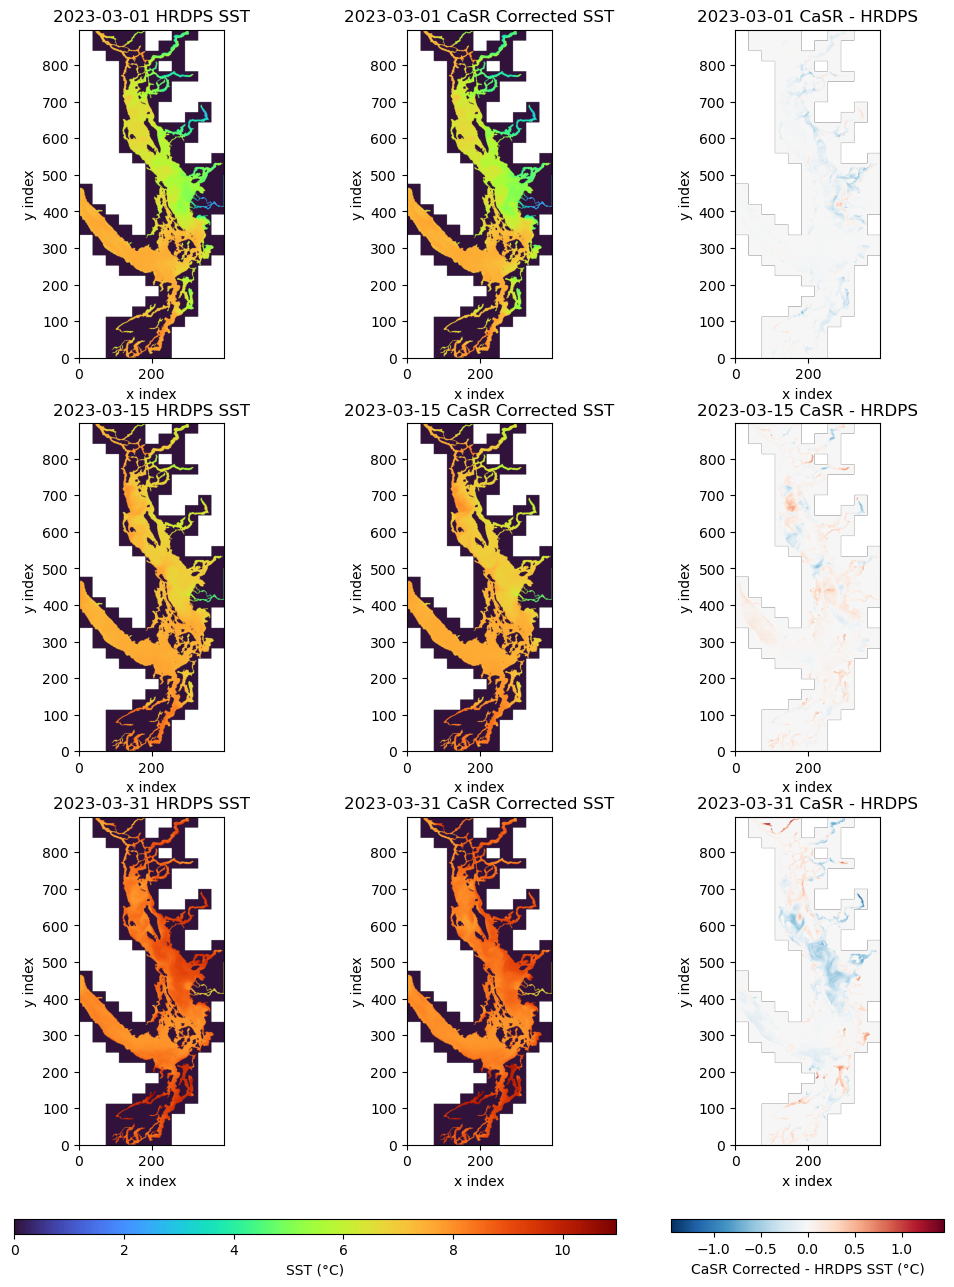

In [1]:
# HRDPS 1km vs HRDPS 2.5 km driven SST

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


# ============================================================
# 1d grid_T files
# ============================================================
path_grid_casr = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR_corrected/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)

path_grid_hrdps = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)


# ============================================================
# Open datasets
# ============================================================
casr_ds = xr.open_dataset(path_grid_casr)
hrdps_ds = xr.open_dataset(path_grid_hrdps)


# ============================================================
# Choose 3 days
#
# For 1d monthly files:
# March 1  -> time index 0
# March 15 -> time index 14
# March 31 -> time index 30
# ============================================================
days = [
    "20230301",
    "20230315",
    "20230331",
]

day_numbers = [1, 15, 31]

depth_idx = 0


# ============================================================
# Read SST data
# ============================================================
all_data = []

for date_str, day_num in zip(days, day_numbers):

    # ========================================================
    # Time index for 1d monthly file
    # ========================================================
    tidx = day_num - 1


    # ========================================================
    # SST
    # ========================================================
    casr_sst = casr_ds['votemper'].isel(
        time_counter=tidx,
        deptht=depth_idx
    ).values

    hrdps_sst = hrdps_ds['votemper'].isel(
        time_counter=tidx,
        deptht=depth_idx
    ).values


    # ========================================================
    # Difference
    # positive = CaSR warmer than HRDPS
    # ========================================================
    diff = casr_sst - hrdps_sst


    # ========================================================
    # Time information
    # ========================================================
    casr_time = casr_ds.time_counter.isel(
        time_counter=tidx
    ).values

    hrdps_time = hrdps_ds.time_counter.isel(
        time_counter=tidx
    ).values


    print("=" * 60)
    print(f"Date        : {date_str}")
    print(f"Time index  : {tidx}")
    print(f"HRDPS 1 time   : {casr_time}")
    print(f"HRDPS time  : {hrdps_time}")
    print(f"HRDPS 1 shape  : {casr_sst.shape}")
    print(f"HRDPS shape : {hrdps_sst.shape}")


    # ========================================================
    # Save for plotting
    # ========================================================
    all_data.append({
        'date': date_str,
        'hrdps': hrdps_sst,
        'casr': casr_sst,
        'diff': diff,
    })


# ============================================================
# Unified SST color range
# across all 3 days and both datasets
# ============================================================
all_sst_values = []

for data in all_data:

    all_sst_values.append(
        data['hrdps'][np.isfinite(data['hrdps'])]
    )

    all_sst_values.append(
        data['casr'][np.isfinite(data['casr'])]
    )

all_sst_values = np.concatenate(all_sst_values)

sst_vmin = np.nanmin(all_sst_values)
sst_vmax = np.nanmax(all_sst_values)


# ============================================================
# Unified difference color range
# symmetric around zero
# ============================================================
all_diff_values = []

for data in all_data:

    all_diff_values.append(
        data['diff'][np.isfinite(data['diff'])]
    )

all_diff_values = np.concatenate(all_diff_values)

diff_max = np.nanmax(np.abs(all_diff_values))

diff_norm = TwoSlopeNorm(
    vmin=-diff_max,
    vcenter=0,
    vmax=diff_max
)


print("\nColor ranges:")
print(f"SST  : {sst_vmin:.3f} to {sst_vmax:.3f} °C")
print(f"Diff : {-diff_max:.3f} to {diff_max:.3f} °C")


# ============================================================
# Plot: 3 rows × 3 columns
#
# column 1: HRDPS SST
# column 2: CaSR SST
# column 3: CaSR - HRDPS
# ============================================================
fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 16)
)


for row, data in enumerate(all_data):

    date_str = data['date']

    hrdps_sst = data['hrdps']
    casr_sst = data['casr']
    diff = data['diff']

    date_label = (
        f'{date_str[:4]}-'
        f'{date_str[4:6]}-'
        f'{date_str[6:]}'
    )


    # ========================================================
    # HRDPS SST
    # ========================================================
    im_sst = axes[row, 0].imshow(
        hrdps_sst,
        origin='lower',
        cmap='turbo',
        vmin=sst_vmin,
        vmax=sst_vmax,
        aspect='equal'
    )

    axes[row, 0].set_title(
        f'{date_label} HRDPS SST'
    )

    axes[row, 0].set_xlabel('x index')
    axes[row, 0].set_ylabel('y index')


    # ========================================================
    # CaSR SST
    # ========================================================
    axes[row, 1].imshow(
        casr_sst,
        origin='lower',
        cmap='turbo',
        vmin=sst_vmin,
        vmax=sst_vmax,
        aspect='equal'
    )

    axes[row, 1].set_title(
        f'{date_label} CaSR Corrected SST'
    )

    axes[row, 1].set_xlabel('x index')
    axes[row, 1].set_ylabel('y index')


    # ========================================================
    # Difference
    # ========================================================
    im_diff = axes[row, 2].imshow(
        diff,
        origin='lower',
        cmap='RdBu_r',
        norm=diff_norm,
        aspect='equal'
    )

    axes[row, 2].set_title(
        f'{date_label} CaSR - HRDPS'
    )

    axes[row, 2].set_xlabel('x index')
    axes[row, 2].set_ylabel('y index')


# # ============================================================
# # Adjust space
# # leave space at bottom for horizontal colorbars
# # ============================================================
# plt.subplots_adjust(
#     left=0.07,
#     right=0.97,
#     top=0.95,
#     bottom=0.12,
#     wspace=0.15,
#     hspace=0.18
# )


# ============================================================
# SST colorbar
# shared by first two columns
# ============================================================
cbar_sst = fig.colorbar(
    im_sst,
    ax=axes[:, 0:2],
    orientation='horizontal',
    fraction=0.035,
    pad=0.06,
    aspect=40
)

cbar_sst.set_label('SST (°C)')


# ============================================================
# Difference colorbar
# shared by third column
# ============================================================
cbar_diff = fig.colorbar(
    im_diff,
    ax=axes[:, 2],
    orientation='horizontal',
    fraction=0.035,
    pad=0.06,
    aspect=20
)

cbar_diff.set_label('CaSR Corrected - HRDPS SST (°C)')


plt.show()


# ============================================================
# Close files
# ============================================================
casr_ds.close()
hrdps_ds.close()

### Scatter plot (also compare with CaSR and HRDPS 10)


Reading March 15, 2023
HRDPS 2.5 file:
/results2/SalishSea/nowcast-green.202111/15mar23/SalishSea_1d_20230315_20230315_grid_T.nc

CaSR Corrected vs HRDPS 2.5:
    N    = 171,030
    RMSE = 0.092 °C
    r    = 1.000

CaSR vs HRDPS 2.5:
    N    = 171,030
    RMSE = 0.203 °C
    r    = 0.998

HRDPS 10 vs HRDPS 2.5:
    N    = 171,030
    RMSE = 0.153 °C
    r    = 0.999

Reading March 31, 2023
HRDPS 2.5 file:
/results2/SalishSea/nowcast-green.202111/31mar23/SalishSea_1d_20230331_20230331_grid_T.nc

CaSR Corrected vs HRDPS 2.5:
    N    = 171,030
    RMSE = 0.145 °C
    r    = 0.999

CaSR vs HRDPS 2.5:
    N    = 171,030
    RMSE = 0.258 °C
    r    = 0.998

HRDPS 10 vs HRDPS 2.5:
    N    = 171,030
    RMSE = 0.139 °C
    r    = 0.999

Common plot range: -1.0 to 12.0 °C


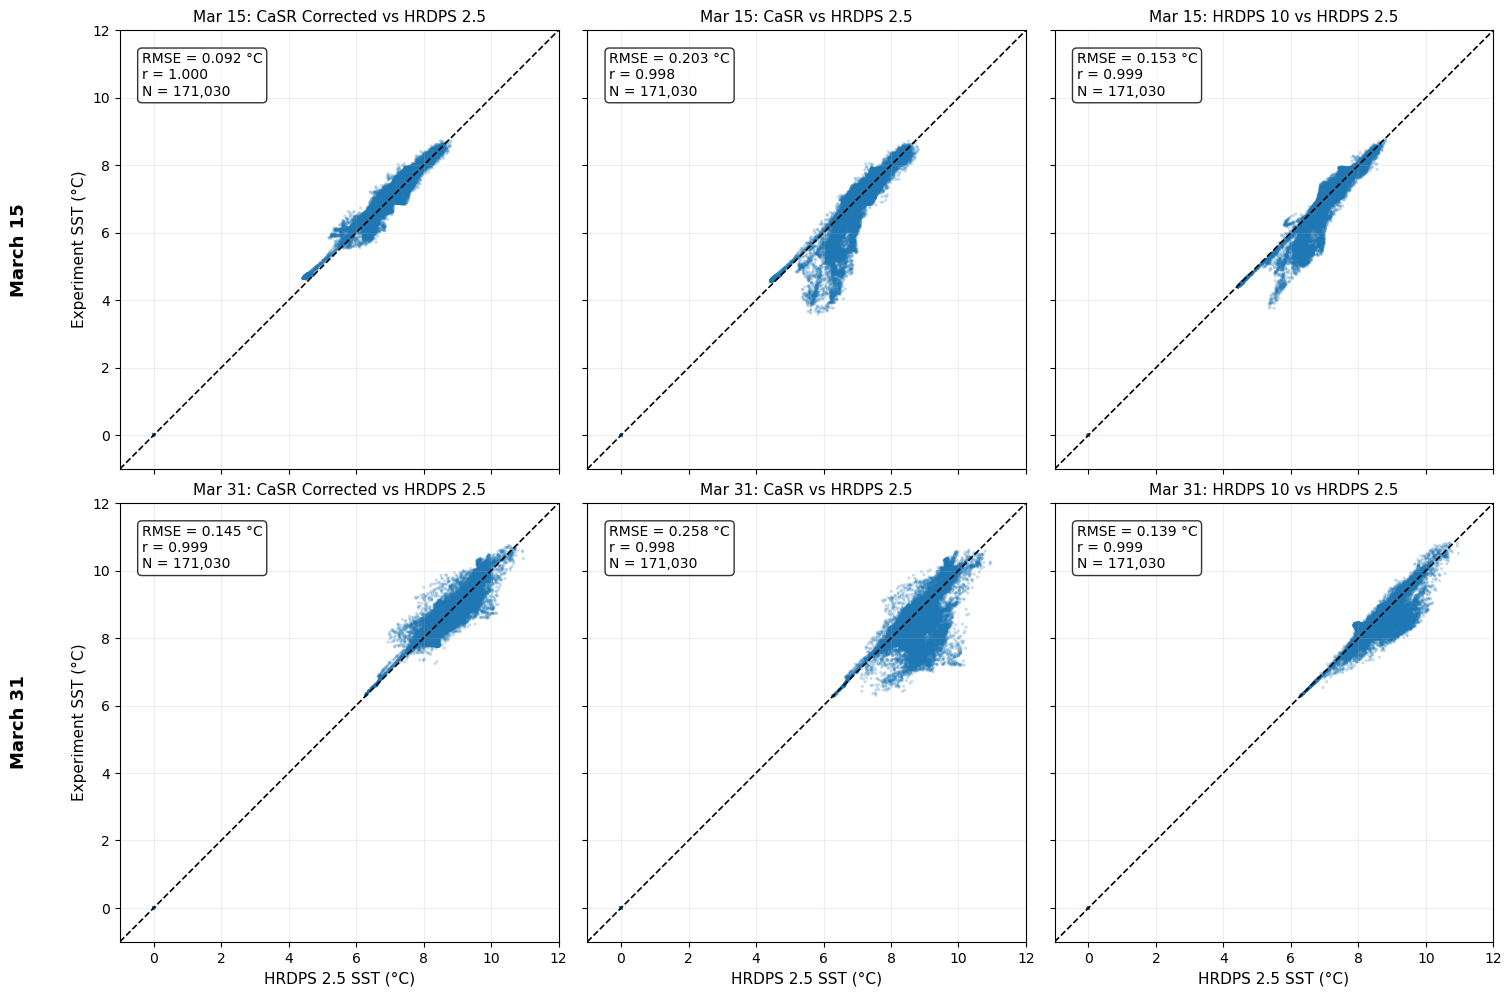

In [3]:
# ============================================================
# Scatter plots of surface SST on March 15 and March 31, 2023
#
# 2 rows x 3 columns:
#
# Columns:
# 1. CaSR Corrected vs HRDPS 2.5
# 2. CaSR           vs HRDPS 2.5
# 3. HRDPS 10       vs HRDPS 2.5
#
# Rows:
# 1. March 15
# 2. March 31
#
# Statistics:
#     RMSE
#     Pearson correlation coefficient r
#
# x-axis = HRDPS 2.5 SST
# y-axis = experiment SST
# ============================================================

import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Paths
# ============================================================

# CaSR Corrected
path_CaSR_corrected = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR_corrected/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)

# CaSR
path_CaSR = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)

# HRDPS 10
path_HRDPS10 = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)

# HRDPS 2.5 daily-file base path
path_HRDPS25_base = (
    '/results2/SalishSea/nowcast-green.202111'
)


# ============================================================
# Configuration
# ============================================================

month_num = 3
month_str = 'mar'

# Days we want to compare
days = [15, 31]

# Surface layer
depth_idx = 0


# ============================================================
# Build HRDPS 2.5 daily path
# ============================================================

def get_hrdps25_path(month_num, month_str, day_num):

    date_str = f'2023{month_num:02d}{day_num:02d}'

    folder = f'{day_num:02d}{month_str}23'

    filename = (
        f'SalishSea_1d_'
        f'{date_str}_{date_str}_grid_T.nc'
    )

    return os.path.join(
        path_HRDPS25_base,
        folder,
        filename
    )


# ============================================================
# Keep only paired finite values
# ============================================================

def get_valid_pairs(reference, experiment):

    reference = np.asarray(reference).ravel()
    experiment = np.asarray(experiment).ravel()

    mask = (
        np.isfinite(reference)
        & np.isfinite(experiment)
    )

    x = reference[mask]
    y = experiment[mask]

    return x, y


# ============================================================
# Calculate RMSE and Pearson correlation
# ============================================================

def calculate_stats(x, y):

    rmse = np.sqrt(
        np.mean((y - x) ** 2)
    )

    if len(x) > 1:
        r = np.corrcoef(x, y)[0, 1]
    else:
        r = np.nan

    return rmse, r


# ============================================================
# Check monthly files
# ============================================================

monthly_paths = {
    'CaSR Corrected': path_CaSR_corrected,
    'CaSR': path_CaSR,
    'HRDPS 10': path_HRDPS10,
}

for name, path in monthly_paths.items():

    if not os.path.exists(path):
        raise FileNotFoundError(
            f'{name} file not found:\n{path}'
        )


# ============================================================
# Open monthly datasets once
# ============================================================

ds_corrected = xr.open_dataset(
    path_CaSR_corrected
)

ds_casr = xr.open_dataset(
    path_CaSR
)

ds_h10 = xr.open_dataset(
    path_HRDPS10
)


# ============================================================
# Read March 15 and March 31
# ============================================================

all_data = []


for day_num in days:

    print(
        f'\n========================================\n'
        f'Reading March {day_num}, 2023\n'
        f'========================================'
    )

    # --------------------------------------------------------
    # Monthly-file time index:
    #
    # March 15 -> index 14
    # March 31 -> index 30
    # --------------------------------------------------------

    tidx = day_num - 1


    # ========================================================
    # HRDPS 2.5 daily file
    # ========================================================

    path_HRDPS25 = get_hrdps25_path(
        month_num=month_num,
        month_str=month_str,
        day_num=day_num
    )

    print(
        f'HRDPS 2.5 file:\n'
        f'{path_HRDPS25}'
    )

    if not os.path.exists(path_HRDPS25):

        raise FileNotFoundError(
            f'HRDPS 2.5 file not found:\n'
            f'{path_HRDPS25}'
        )


    # ========================================================
    # Open HRDPS 2.5 daily dataset
    # ========================================================

    ds_h25 = xr.open_dataset(
        path_HRDPS25
    )


    # ========================================================
    # Surface SST
    # ========================================================

    # CaSR Corrected
    sst_corrected = ds_corrected['votemper'].isel(
        time_counter=tidx,
        deptht=depth_idx
    ).values


    # CaSR
    sst_casr = ds_casr['votemper'].isel(
        time_counter=tidx,
        deptht=depth_idx
    ).values


    # HRDPS 10
    sst_h10 = ds_h10['votemper'].isel(
        time_counter=tidx,
        deptht=depth_idx
    ).values


    # HRDPS 2.5
    # Daily file -> time index = 0
    sst_h25 = ds_h25['votemper'].isel(
        time_counter=0,
        deptht=depth_idx
    ).values


    # ========================================================
    # Valid paired data
    # ========================================================

    # CaSR Corrected vs HRDPS 2.5
    x_corrected, y_corrected = get_valid_pairs(
        sst_h25,
        sst_corrected
    )


    # CaSR vs HRDPS 2.5
    x_casr, y_casr = get_valid_pairs(
        sst_h25,
        sst_casr
    )


    # HRDPS 10 vs HRDPS 2.5
    x_h10, y_h10 = get_valid_pairs(
        sst_h25,
        sst_h10
    )


    # ========================================================
    # Statistics
    # ========================================================

    rmse_corrected, r_corrected = calculate_stats(
        x_corrected,
        y_corrected
    )

    rmse_casr, r_casr = calculate_stats(
        x_casr,
        y_casr
    )

    rmse_h10, r_h10 = calculate_stats(
        x_h10,
        y_h10
    )


    # ========================================================
    # Print statistics
    # ========================================================

    print(
        f'\nCaSR Corrected vs HRDPS 2.5:\n'
        f'    N    = {len(x_corrected):,}\n'
        f'    RMSE = {rmse_corrected:.3f} °C\n'
        f'    r    = {r_corrected:.3f}'
    )

    print(
        f'\nCaSR vs HRDPS 2.5:\n'
        f'    N    = {len(x_casr):,}\n'
        f'    RMSE = {rmse_casr:.3f} °C\n'
        f'    r    = {r_casr:.3f}'
    )

    print(
        f'\nHRDPS 10 vs HRDPS 2.5:\n'
        f'    N    = {len(x_h10):,}\n'
        f'    RMSE = {rmse_h10:.3f} °C\n'
        f'    r    = {r_h10:.3f}'
    )


    # ========================================================
    # Save
    # ========================================================

    all_data.append({

        'day': day_num,

        'corrected': {
            'x': x_corrected,
            'y': y_corrected,
            'rmse': rmse_corrected,
            'r': r_corrected,
        },

        'casr': {
            'x': x_casr,
            'y': y_casr,
            'rmse': rmse_casr,
            'r': r_casr,
        },

        'h10': {
            'x': x_h10,
            'y': y_h10,
            'rmse': rmse_h10,
            'r': r_h10,
        },
    })


    # Close daily file
    ds_h25.close()


# ============================================================
# Common temperature range for ALL 6 panels
# ============================================================

all_temperature = []

for data in all_data:

    for key in ['corrected', 'casr', 'h10']:

        all_temperature.extend([
            data[key]['x'],
            data[key]['y']
        ])


all_temperature = np.concatenate(
    all_temperature
)


temp_min = np.nanmin(
    all_temperature
)

temp_max = np.nanmax(
    all_temperature
)


padding = 0.5

plot_min = np.floor(
    temp_min - padding
)

plot_max = np.ceil(
    temp_max + padding
)


print(
    f'\nCommon plot range: '
    f'{plot_min:.1f} to {plot_max:.1f} °C'
)


# ============================================================
# Plot configuration
# ============================================================

columns = [

    (
        'corrected',
        'CaSR Corrected'
    ),

    (
        'casr',
        'CaSR'
    ),

    (
        'h10',
        'HRDPS 10'
    ),
]


# ============================================================
# Plot
#
# 2 rows x 3 columns
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 10),
    sharex=True,
    sharey=True
)


# ============================================================
# Loop through days / rows
# ============================================================

for row, data in enumerate(all_data):

    day_num = data['day']


    # ========================================================
    # Loop through experiments / columns
    # ========================================================

    for col, (key, name) in enumerate(columns):

        ax = axes[row, col]

        d = data[key]


        # ----------------------------------------------------
        # Scatter
        # ----------------------------------------------------

        ax.scatter(
            d['x'],
            d['y'],
            s=5,
            alpha=0.25,
            edgecolors='none'
        )


        # ----------------------------------------------------
        # 1:1 line
        # ----------------------------------------------------

        ax.plot(
            [plot_min, plot_max],
            [plot_min, plot_max],
            'k--',
            linewidth=1.2
        )


        # ----------------------------------------------------
        # Common limits
        # ----------------------------------------------------

        ax.set_xlim(
            plot_min,
            plot_max
        )

        ax.set_ylim(
            plot_min,
            plot_max
        )


        # Equal x/y scale
        ax.set_aspect(
            'equal',
            adjustable='box'
        )


        # ----------------------------------------------------
        # Title
        # ----------------------------------------------------

        ax.set_title(
            f'Mar {day_num:02d}: '
            f'{name} vs HRDPS 2.5',
            fontsize=11
        )


        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        ax.text(
            0.05,
            0.95,
            (
                f"RMSE = {d['rmse']:.3f} °C\n"
                f"r = {d['r']:.3f}\n"
                f"N = {len(d['x']):,}"
            ),
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=10,
            bbox=dict(
                boxstyle='round',
                facecolor='white',
                alpha=0.8
            )
        )


        # ----------------------------------------------------
        # Grid
        # ----------------------------------------------------

        ax.grid(
            alpha=0.2
        )


# ============================================================
# Y labels
# ============================================================

axes[0, 0].set_ylabel(
    'Experiment SST (°C)',
    fontsize=11
)

axes[1, 0].set_ylabel(
    'Experiment SST (°C)',
    fontsize=11
)


# ============================================================
# X labels
# ============================================================

for col in range(3):

    axes[1, col].set_xlabel(
        'HRDPS 2.5 SST (°C)',
        fontsize=11
    )


# ============================================================
# Optional row labels
# ============================================================

axes[0, 0].annotate(
    'March 15',
    xy=(-0.23, 0.5),
    xycoords='axes fraction',
    rotation=90,
    va='center',
    ha='center',
    fontsize=13,
    fontweight='bold'
)

axes[1, 0].annotate(
    'March 31',
    xy=(-0.23, 0.5),
    xycoords='axes fraction',
    rotation=90,
    va='center',
    ha='center',
    fontsize=13,
    fontweight='bold'
)


# ============================================================
# Layout
# ============================================================

plt.tight_layout()

plt.show()


# ============================================================
# Close monthly datasets
# ============================================================

ds_corrected.close()
ds_casr.close()
ds_h10.close()